# Imidazolone & Thiazolone Hit Prioritisation — Second Phase

Phase 2 prioritization for generated COX-2 inhibitor candidates derived from Phase 1 product sets.

**Pipeline:** ```Generated products → QED scoring → Bioavailability filter (4/5 rules) → ML-QSAR winnow → ALMOS clustering```

**Series handling:** Imidazolones and thiazolones are processed as two
independent datasets.

**Visualization:** QED histograms are generated for accepted and rejected
sets using the combined distributions of both series.

**Clustering input control:** clustering inputs are the ML-QSAR outputs
passed directly to `py_utils.clustering.cluster_inputs`.

***(Please read [the second phase README.md](02_selected_mols_data/README.md) for full details on this notebook).***

In [22]:
from __future__ import annotations

import sys
import pandas as pd

sys.path.insert(0, "02_selected_mols_data")
import modules as hp
from modules import clustering as clt


FORCE_RECOMPUTE = False
INPUT_FILTER_MODE = ""

# ALMOS clustering options
ALMOS_CONDA_ENV = None
TOP_N_PER_CLUSTER = 3
N_CLUSTERS_IMIDAZOLONES = None
N_CLUSTERS_THIAZOLONES = None

# QSAR winnow options
QSAR_ACCEPTANCE_RATE = 0.05
QSAR_MINIMUM = 100

print("winnowing module loaded")
print(f"Input filter mode: {INPUT_FILTER_MODE}")
print(f"Force recompute QED cache: {FORCE_RECOMPUTE}")

winnowing module loaded
Input filter mode: 
Force recompute QED cache: False


## 📥 11. Load Generated Products

Load the latest counted CSV files from Phase 1 (Brenk+PAINS outputs) for
both product families.

In [23]:
df_imidazolones_generated, df_thiazolones_generated, imidazolones_source, thiazolones_source = hp.load_generated_product_sets(
    filter_mode=INPUT_FILTER_MODE,
)

hp.report_df_size(df_imidazolones_generated, "Imidazolones - Generated")
hp.report_df_size(df_thiazolones_generated, "Thiazolones - Generated")

[LoadProducts] Imidazolones: Imidazolones_177cmpds.csv (177 rows)
[LoadProducts] Thiazolones:  Thiazolones_45cmpds.csv (45 rows)
[Imidazolones - Generated] 177 rows
[Thiazolones - Generated] 45 rows


## ⬥ 12. QED Scoring

Compute Quantitative Estimate of Drug-likeness (QED) and insert it between
`PriceMol` and `tPSA`.

> Cache is stored in `02_selected_mols_data/.interim/qed/.cache/` for restart-safe reuse.

In [24]:
df_imidazolones_qed, imidazolones_qed_cache = hp.load_or_compute_qed(
    df_imidazolones_generated,
    stage_name="Imidazolones",
    force_recompute=FORCE_RECOMPUTE,
)
df_thiazolones_qed, thiazolones_qed_cache = hp.load_or_compute_qed(
    df_thiazolones_generated,
    stage_name="Thiazolones",
    force_recompute=FORCE_RECOMPUTE,
)

hp.report_df_size(df_imidazolones_qed, "Imidazolones - QED")
hp.report_df_size(df_thiazolones_qed, "Thiazolones - QED")

[load_or_compute_qed] Computing QED for Imidazolones...
[QED] Computed 177/177 values (0 missing)
[load_or_compute_qed] Saved Imidazolones_qed_177cmpds.csv (177 rows)
[load_or_compute_qed] Computing QED for Thiazolones...
[QED] Computed 45/45 values (0 missing)
[load_or_compute_qed] Saved Thiazolones_qed_45cmpds.csv (45 rows)
[Imidazolones - QED] 177 rows
[Thiazolones - QED] 45 rows


## 🔸 13. Bioavailability Filter (⅘ Rule Set)

Apply Lipinski, Ghose, Egan, Muegge, and Veber criteria and keep compounds
with at most one violated rule.

`Violation` is inserted immediately after `QED` and stores violated rule
names (`none` when no rule is violated).

Save accepted and rejected sets in `02_selected_mols_data/.interim/qed/` using row-count
suffix naming conventions.

In [25]:
df_imidazolones_druglike, df_imidazolones_nondruglike = hp.filter_bioavailability(df_imidazolones_qed)
df_thiazolones_druglike, df_thiazolones_nondruglike = hp.filter_bioavailability(df_thiazolones_qed)

hp.report_df_size(df_imidazolones_druglike, "Imidazolones - Druglike")
hp.report_df_size(df_thiazolones_druglike, "Thiazolones - Druglike")
hp.report_df_size(df_imidazolones_nondruglike, "Imidazolones - NonDruglike")
hp.report_df_size(df_thiazolones_nondruglike, "Thiazolones - NonDruglike")

bioavailability_paths = hp.save_bioavailability_outputs(
    df_imidazolones_druglike=df_imidazolones_druglike,
    df_thiazolones_druglike=df_thiazolones_druglike,
    df_imidazolones_nondruglike=df_imidazolones_nondruglike,
    df_thiazolones_nondruglike=df_thiazolones_nondruglike,
)

[filter_bioavailability] 177/177 accepted (100.0%), 0 rejected
[filter_bioavailability] 43/45 accepted (95.6%), 2 rejected
[Imidazolones - Druglike] 177 rows
[Thiazolones - Druglike] 43 rows
[Imidazolones - NonDruglike] 0 rows
[Thiazolones - NonDruglike] 2 rows
[Save] 02_selected_mols_data/.interim/qed/Imidazolones_177cmpds.csv
[Save] 02_selected_mols_data/.interim/qed/Thiazolones_43cmpds.csv
[Save] 02_selected_mols_data/.interim/qed/.rejected/Imidazolones_rejected_bioavailability_0cmpds.csv
[Save] 02_selected_mols_data/.interim/qed/.rejected/Thiazolones_rejected_bioavailability_2cmpds.csv


## 📊 14. QED Distribution

Plot QED histograms for:
- Rejected compounds (imidazolones + thiazolones)
- Accepted compounds (imidazolones + thiazolones)

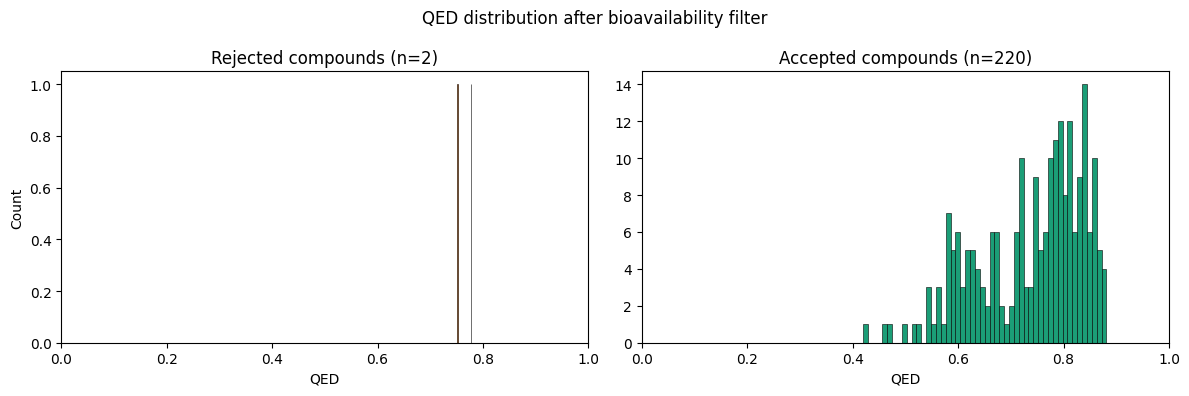

In [26]:
_fig, _axes = hp.plot_qed_histograms(
    df_imidazolones_druglike=df_imidazolones_druglike,
    df_thiazolones_druglike=df_thiazolones_druglike,
    df_imidazolones_nondruglike=df_imidazolones_nondruglike,
    df_thiazolones_nondruglike=df_thiazolones_nondruglike,
)

## 🔸 15. ML-QSAR Winnow

Train Random Forest models on ChEMBL IC50 data, predict pIC50 for both series,
compute QSAR score (2×pIC50_COX2 - pIC50_COX1), and select top compounds.

Selection rule per series: `keep_n = min(N, max(int(N * QSAR_ACCEPTANCE_RATE), QSAR_MINIMUM))`.

Save QSAR outputs to `02_selected_mols_data/.interim/qsar/` with row-count suffix naming conventions.

In [27]:
qsar_outputs, qsar_paths = hp.run_qsar_winnow(
    df_imidazolones_druglike=df_imidazolones_druglike,
    df_thiazolones_druglike=df_thiazolones_druglike,
    acceptance_rate=QSAR_ACCEPTANCE_RATE,
    minimum=QSAR_MINIMUM,
)

print("\n=== ML-QSAR Winnow Complete ===")
print(f"Imidazolones QSAR: {len(qsar_outputs['imidazolones_accepted']):,} accepted")
print(f"Thiazolones QSAR:  {len(qsar_outputs['thiazolones_accepted']):,} accepted")

[QSAR] Removed 1 rows with NaN SMILES
[QSAR] Removed 0 empty/blank SMILES
[QSAR] Removed 0 invalid SMILES
[QSAR] ChEMBL rows with descriptors: 4,349
[QSAR] COX2 RF regressor: MAE=0.776, RMSE=1.059, R2=0.347
[QSAR] COX2 RF classifier: Accuracy=0.734
[QSAR] AD cutoff (95th percentile): 4.864
[QSAR] Saved model cache: 02_selected_mols_data/.interim/qsar/.cache/qsar_models.json.gz
[QSAR Imidazolones] Removed 0 rows with NaN SMILES
[QSAR Imidazolones] Removed 0 empty/blank SMILES
[QSAR Imidazolones] Removed 0 invalid SMILES
[QSAR Imidazolones] Rows with descriptors: 177
[QSAR Thiazolones] Removed 0 rows with NaN SMILES
[QSAR Thiazolones] Removed 0 empty/blank SMILES
[QSAR Thiazolones] Removed 0 invalid SMILES
[QSAR Thiazolones] Rows with descriptors: 43
[QSAR] Selection counts (max of 5.00% vs 100): Imidazolones keep_n=100 (5.00%=8), Thiazolones keep_n=43 (5.00%=2)
[QSAR] Imidazolones: 100 accepted, 77 rejected
[QSAR] Thiazolones: 43 accepted, 0 rejected
[Save] 02_selected_mols_data/.interi

## 📤 16. ALMOS Clustering

Run ALMOS directly from this notebook using the QSAR-accepted DataFrames.

- Keep imidazolones and thiazolones fully separate
- Use descriptor mode (no `--aqme`)
- If `ID` contains duplicates, `py_utils.clustering` auto-generates a
  unique temporary ALMOS name column and maps clusters back to the original rows

In [28]:
from modules import clustering as clt

almos_outputs = clt.cluster_inputs(
    imidazolones_input_csv=qsar_paths['imidazolones_accepted'],
    thiazolones_input_csv=qsar_paths['thiazolones_accepted'],
    n_clusters_imidazolones=N_CLUSTERS_IMIDAZOLONES,
    n_clusters_thiazolones=N_CLUSTERS_THIAZOLONES,
    top_n_per_cluster=TOP_N_PER_CLUSTER,
    conda_env=ALMOS_CONDA_ENV,
)

print('\n=== ALMOS Clustering Complete ===')
for series, paths in almos_outputs.items():
    print(f"{series.title()}: {len(paths)} outputs")

[validate_distinct_series_inputs] Imidazolones: rows=100, sha256=98485cd64415...
[validate_distinct_series_inputs] Thiazolones:  rows=43, sha256=994d5a21988e...
⚠️ [validate_clustering_input] Found 6 duplicate IDs in 'ID'.
[validate_clustering_input] rows=100, descriptor_cols=22, numeric_like_cols=22
⚠️ [cluster_with_almos] Imidazolones: found 6 duplicated values in 'ID'. Generated unique 'ALMOS_ID' for ALMOS.
[run_almos_cluster] --input 02_selected_mols_data/.interim/ALMOS/.runs/Imidazolones_20260511T220657Z/Imidazolones_qsar_100cmpds_almos_input.csv
[run_almos_cluster] cwd=02_selected_mols_data/.interim/ALMOS/.runs/Imidazolones_20260511T220657Z
[run_almos_cluster] Generated CSV files: 4
[save_clustering_outputs] 02_selected_mols_data/.interim/ALMOS/Imidazolones_clusters_k15_100cmpds.csv
[save_clustering_outputs] 02_selected_mols_data/.interim/ALMOS/Imidazolones_representatives_k15_15cmpds.csv
[save_clustering_outputs] Imidazolones_15samples.csv
[save_clustering_outputs] 02_selected_m